# 02 — Validation: 3-way model comparison (multi-quarter)

Compare three prediction variants across **all available quarters** (2025Q4–2026Q3)
to separate signal from quarter-specific noise. Each quarter gets its own random
sample (N=250, different seed per quarter to avoid overlap). Results are aggregated
into a mean ΔR² ± std across quarters.

| Module | Rulebook | Insider (Form 4) | Ensembling | Description |
|---|---|---|---|---|
| `predict.py` | dynamic (rulebook.json) | yes | 3× | current live Frankfurt-2.2 |
| `predict_02_submitted.py` | static (3 bullets in SYSTEM_PROMPT) | no | no | the submitted version |
| `predict_first.py` | none | no | no | bare minimum — system prompt + summary only |

Results are cached to `validation_cache.json` — event_ids are unique across quarters,
so the cache accumulates across all periods automatically.

In [1]:
from pathlib import Path

from examples import Client, load_config
from examples.archive import download_archive, load_archive
from examples.frames import manifest_frame

def _find_repo() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "data" / "sample").is_dir():
            return p
        if (p / "examples" / "data" / "sample").is_dir():
            return p / "examples"
    raise FileNotFoundError("Could not find examples/data/sample")

REPO = _find_repo()
ARCHIVE_DIR = REPO / "data" / "archive"
SAMPLE_DIR = REPO / "data" / "sample"

config = load_config()
print("Mode:", "LIVE" if config.is_live else "SAMPLE")

# Load archive
if config.is_live:
    with Client.from_env() as client:
        manifest = client.archive_manifest()
        paths = download_archive(manifest, ARCHIVE_DIR, client=client)
    source = ARCHIVE_DIR
else:
    source = SAMPLE_DIR

df = load_archive(source)
print(f"Loaded {len(df):,} events")

Mode: LIVE
skip     EARNINGS_RELEASE_2025Q4.jsonl.gz (cached, 1,036,733 bytes)
skip     EARNINGS_RELEASE_2026Q1.jsonl.gz (cached, 1,625,978 bytes)
skip     EARNINGS_RELEASE_2026Q2.jsonl.gz (cached, 1,710,368 bytes)
skip     EARNINGS_RELEASE_2026Q3.jsonl.gz (cached, 1,620,210 bytes)
Loaded 8,335 events


In [2]:
from examples.scoring import add_percentiles, outcomes_frame

PERIODS = ["2025Q4", "2026Q1", "2026Q2", "2026Q3"]
PERIODS = [p for p in PERIODS if (df["quarter"] == p).any()]

needed = {"event_returns", "metrics", "baseline_predictions"}
have_scoring_data = needed <= set(df.columns)

if have_scoring_data:
    scored_by_quarter = {}
    for period in PERIODS:
        records = df[df["quarter"] == period].to_dict("records")
        scored_by_quarter[period] = add_percentiles(outcomes_frame(records))
        print(f"  {period}: {len(scored_by_quarter[period]):,} scored outcomes")
    print(f"\n{len(PERIODS)} quarters with scoring data")
else:
    print("Sample mode — needs live archive.")
    scored_by_quarter = {}

  2025Q4: 1,849 scored outcomes
  2026Q1: 2,390 scored outcomes
  2026Q2: 2,060 scored outcomes
  2026Q3: 2,035 scored outcomes

4 quarters with scoring data


In [3]:
import sys
import pandas as pd

# Use ALL quarters — period_df is filtered per-quarter inside the backtest loop
REPO_ROOT = REPO.parent
for _path in (REPO_ROOT, REPO_ROOT / "submissions", REPO_ROOT / "variants"):
    if str(_path) not in sys.path:
        sys.path.insert(0, str(_path))

import predict
import predict_02_submitted
import predict_first

print("predict.py:              dynamic rulebook + insider + 3x ensemble")
print("predict_02_submitted.py:  static 3-bullet rulebook, no insider, single draw")
print("predict_first.py:         no rulebook, no insider, single draw — base prompt only")
print("DEEPSEEK_API_KEY set:", bool(__import__("os").environ.get("DEEPSEEK_API_KEY")))

def facts_to_summary(disclosure: dict) -> str:
    lines = []
    for item in disclosure.get("items", []):
        if item.get("kind") == "facts":
            lines.extend(item["content"])
    return "\n".join(f"- {f}" for f in lines)

predict.py:              dynamic rulebook + insider + 3x ensemble
predict_02_submitted.py:  static 3-bullet rulebook, no insider, single draw
predict_first.py:         no rulebook, no insider, single draw — base prompt only
DEEPSEEK_API_KEY set: True


In [4]:
from data_provider.yfinance import get_sector

# Prefetch sectors for ALL tickers across all quarters (disk-cached, cheap on re-run).
# peer_momentum is not currently wired into the backtest below, but having sectors
# cached makes it trivial to re-add later.
all_tickers = sorted({
    a["identifier_value"]
    for _, r in df.iterrows()
    for a in r["focal_assets"]
})
print(f"Prefetching sector for {len(all_tickers)} unique tickers (all quarters)...")
for i, t in enumerate(all_tickers, 1):
    get_sector(t)
    if i % 50 == 0 or i == len(all_tickers):
        print(f"  {i}/{len(all_tickers)}")
print("Done — sectors cached to disk.")

Prefetching sector for 2632 unique tickers (all quarters)...
  50/2632
  100/2632
  150/2632
  200/2632
  250/2632
  300/2632
  350/2632
  400/2632
  450/2632
  500/2632
  550/2632
  600/2632
  650/2632
  700/2632
  750/2632
  800/2632
  850/2632
  900/2632
  950/2632
  1000/2632
  1050/2632
  1100/2632
  1150/2632
  1200/2632
  1250/2632
  1300/2632
  1350/2632
  1400/2632
  1450/2632
  1500/2632
  1550/2632
  1600/2632
  1650/2632
  1700/2632
  1750/2632
  1800/2632
  1850/2632
  1900/2632
  1950/2632
  2000/2632
  2050/2632
  2100/2632
  2150/2632
  2200/2632
  2250/2632
  2300/2632
  2350/2632
  2400/2632
  2450/2632
  2500/2632
  2550/2632
  2600/2632
  2632/2632
Done — sectors cached to disk.


In [5]:
import json, os, threading
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

CACHE_PATH = Path.cwd() / "validation_cache.json"
N_DRAWS = 1
MAX_WORKERS = 5

def load_cache(path: Path) -> dict:
    if not path.exists() or path.stat().st_size == 0:
        return {}
    try:
        return json.loads(path.read_text())
    except json.JSONDecodeError:
        print(f"[WARN] {path.name} corrupt — starting fresh.")
        return {}

def save_cache(path: Path, data: dict) -> None:
    tmp = path.with_suffix(".tmp")
    tmp.write_text(json.dumps(data, indent=2))
    os.replace(tmp, path)

cache = load_cache(CACHE_PATH)
cache_lock = threading.Lock()

N_SAMPLE = 100
# Use the same seed per quarter for reproducibility, but different seeds
# across quarters to avoid picking the same 250 events in every quarter
# (which would artificially inflate cross-quarter consistency).
for qi, PERIOD in enumerate(PERIODS):
    period_df = df[df["quarter"] == PERIOD].copy()
    sample_df = period_df.sample(n=min(N_SAMPLE, len(period_df)), random_state=qi)
    todo = [row for _, row in sample_df.iterrows() if row["event_id"] not in cache]
    print(f"\n--- {PERIOD}: {len(sample_df) - len(todo)} cached, {len(todo)} to run ---")

    if not todo:
        continue

    def predict_one(row):
        summary_text = facts_to_summary(row["disclosure"])
        tickers = [a["identifier_value"] for a in row["focal_assets"]]
        momentum_text = "n/a"  # peer_momentum not used in multi-quarter loop

        preds = {"predict": {}, "predict_02": {}, "predict_first": {}}
        for ticker in tickers:
            # predict.py
            preds["predict"][ticker] = predict._ask_llm(
                summary={"summary": summary_text},
                ticker=ticker,
                event_type=row["event_type"],
                as_of=row["knowledge_cutoff"],
            ).predicted_percentile
            # predict_02_submitted.py
            preds["predict_02"][ticker] = predict_02_submitted._ask_llm(
                summary={"summary": summary_text},
                ticker=ticker,
                event_type=row["event_type"],
                as_of=row["knowledge_cutoff"],
            )
            # predict_first.py
            preds["predict_first"][ticker] = predict_first._ask_llm(
                summary={"summary": summary_text},
                ticker=ticker,
                event_type=row["event_type"],
                as_of=row["knowledge_cutoff"],
            )
        return row["event_id"], preds

    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as pool:
        futures = {pool.submit(predict_one, row): row["event_id"] for row in todo}
        done = 0
        for future in as_completed(futures):
            event_id = futures[future]
            try:
                event_id, preds = future.result()
            except Exception as e:
                print(f"[ERROR] {event_id}: {e!r} — skipping")
                continue
            with cache_lock:
                cache[event_id] = preds
                save_cache(CACHE_PATH, cache)
            done += 1
            if done % 50 == 0 or done == len(todo):
                print(f"  {done}/{len(todo)} done")

print(f"\n{len(cache)} events total in {CACHE_PATH.name}")


--- 2025Q4: 0 cached, 100 to run ---

==================== predict.py -- SYSTEM PROMPT (call #1) ====================
You are a senior equity analyst predicting how a stock will react to an event.

Predict a single percentile in [0, 1] for how the focal asset's next-day
abnormal return will rank across all of the quarter's event outcomes:
0 = the quarter's most negative reaction, 0.50 = median, 1 = its most positive.
The relevant return is the *unexpected*, market-adjusted return — a
great-but-fully-priced-in beat is not a top-decile event.

Calibration discipline:
- Long-run base rates: about 25% of events land "up" (>0.75), 50% "neutral"
  (0.25-0.75), 25% "down" (<0.25). Default toward 0.40-0.60 when signals are
  mixed or modest.
- Reserve values above 0.80 or below 0.20 for cases with unambiguous,
  multi-signal evidence. Do not exceed 0.90 or fall below 0.10 without
  overwhelming, lopsided evidence.
- Tone alone (confident vs hedging language) should move you no more than
  ~0.

In [6]:
from examples.scoring import score_submission

MODELS = [
    ("predict",      "predict.py (full stack)"),
    ("predict_02",   "predict_02_submitted.py (static rulebook)"),
    ("predict_first","predict_first.py (bare minimum)"),
]

# Score per quarter, then aggregate
all_results = {}  # {period: {model_key: result_dict}}

for PERIOD in PERIODS:
    period_scored = scored_by_quarter[PERIOD]
    print(f"\n=== {PERIOD} ===")
    qr = {}
    for key, label in MODELS:
        rows = [
            {"event_id": eid, "identifier_value": tk, "predicted": pct}
            for eid, preds in cache.items()
            for tk, pct in preds[key].items()
        ]
        pred_df = pd.DataFrame(rows)
        merged = period_scored.merge(pred_df, on=["event_id", "identifier_value"], how="left")
        covered = merged["predicted"].notna().sum()
        r = score_submission(merged, "predicted")
        qr[key] = r
        print(f"  {label:<40} n={r['n_obs']:>4}  R²={r['r_squared']:.4f}  ΔR²={r['delta_r_squared']:.4f}")
    all_results[PERIOD] = qr

# --- Aggregate table ---
print("\n" + "=" * 70)
print("AGGREGATE: Mean ΔR² across quarters")
print(f"{'Variant':<40} {'2025Q4':>8} {'2026Q1':>8} {'2026Q2':>8} {'2026Q3':>8} {'MEAN':>8}")
print("-" * 75)
for key, label in MODELS:
    vals = []
    row_str = f"{label:<40}"
    for p in PERIODS:
        v = all_results.get(p, {}).get(key, {})
        d = v.get("delta_r_squared", float("nan"))
        vals.append(d)
        row_str += f" {d:>8.4f}"
    mean_d = sum(v for v in vals if v == v) / max(1, sum(1 for v in vals if v == v))
    row_str += f" {mean_d:>8.4f}"
    print(row_str)

# Store predict.py results for the plot cell
results = all_results[PERIODS[-1]]  # latest quarter as single-q reference


=== 2025Q4 ===
  predict.py (full stack)                  n= 100  R²=0.1285  ΔR²=0.0678
  predict_02_submitted.py (static rulebook) n= 100  R²=0.1122  ΔR²=0.0515
  predict_first.py (bare minimum)          n= 100  R²=0.1808  ΔR²=0.1201

=== 2026Q1 ===
  predict.py (full stack)                  n=  96  R²=0.1102  ΔR²=0.0494
  predict_02_submitted.py (static rulebook) n=  96  R²=0.1722  ΔR²=0.1114
  predict_first.py (bare minimum)          n=  96  R²=0.1631  ΔR²=0.1023

=== 2026Q2 ===
  predict.py (full stack)                  n=  97  R²=0.1224  ΔR²=0.0278
  predict_02_submitted.py (static rulebook) n=  97  R²=0.1011  ΔR²=0.0065
  predict_first.py (bare minimum)          n=  97  R²=0.0967  ΔR²=0.0021

=== 2026Q3 ===
  predict.py (full stack)                  n=  95  R²=0.0945  ΔR²=0.0141
  predict_02_submitted.py (static rulebook) n=  95  R²=0.1532  ΔR²=0.0728
  predict_first.py (bare minimum)          n=  95  R²=0.1781  ΔR²=0.0976

AGGREGATE: Mean ΔR² across quarters
Variant            

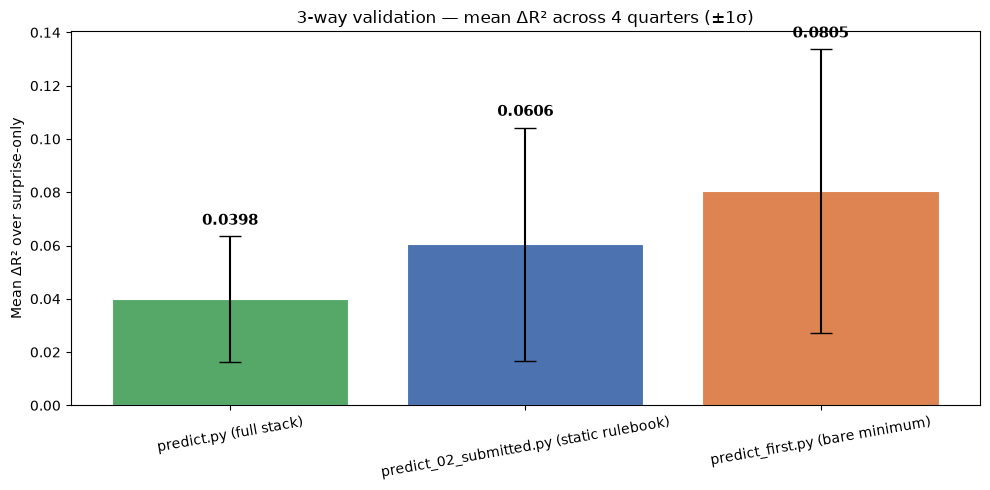


Per-quarter ΔR²:
  predict.py (full stack)                  [0.0678  0.0494  0.0278  0.0141]  → mean 0.0398
  predict_02_submitted.py (static rulebook) [0.0515  0.1114  0.0065  0.0728]  → mean 0.0606
  predict_first.py (bare minimum)          [0.1201  0.1023  0.0021  0.0976]  → mean 0.0805


In [7]:
import matplotlib.pyplot as plt
import numpy as np

labels = [label for _, label in MODELS]
colors = ["#55A868", "#4C72B0", "#DD8452"]

# Collect per-quarter ΔR² for each model
dr2_by_model = {key: [] for key, _ in MODELS}
for p in PERIODS:
    for key, _ in MODELS:
        dr2_by_model[key].append(all_results[p][key]["delta_r_squared"])

means = [np.mean(dr2_by_model[key]) for key, _ in MODELS]
stds  = [np.std(dr2_by_model[key], ddof=1) if len(dr2_by_model[key]) > 1 else 0 for key, _ in MODELS]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, means, yerr=stds, color=colors, capsize=8, edgecolor="white", linewidth=0.8)
ax.set_ylabel("Mean ΔR² over surprise-only")
ax.set_title(f"3-way validation — mean ΔR² across {len(PERIODS)} quarters (±1σ)")
ax.tick_params(axis="x", labelrotation=10)

# Annotate bars
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.003,
            f"{m:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

# Per-quarter detail
print("\nPer-quarter ΔR²:")
for key, label in MODELS:
    vals_str = "  ".join(f"{all_results[p][key]['delta_r_squared']:.4f}" for p in PERIODS if p in all_results and key in all_results[p])
    print(f"  {label:<40} [{vals_str}]  → mean {means[MODELS.index((key,label))]:.4f}")